# Maize Disease Prediction Model

Train a CNN to classify maize leaf images into: **Blight**, **Common_Rust**, **Gray_Leaf_Spot**, **Healthy**.
Uses pretrained ResNet18 and stratified train/val split.

**Importing all the libraries required**  
In the next cell we import PyTorch, torchvision, sklearn, PIL, and matplotlib, and set the device (GPU if available).

In [2]:
import os
import random
import json
import numpy as np
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


**Setting config and discovering classes**  
In the next cell we set data path, image size, batch size, epochs, learning rate, and seed; then list the class folders (Blight, Common_Rust, Gray_Leaf_Spot, Healthy) from `data/maize`.

In [3]:
# Config
MAIZE_ROOT = Path("..") / "data" / "maize"
assert MAIZE_ROOT.exists(), f"Maize root not found at {MAIZE_ROOT}"
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-3
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

class_names = sorted([d.name for d in MAIZE_ROOT.iterdir() if d.is_dir()])
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)

# Standardized export/display class names for maize model, mapped from folder names
_folder_to_export = {
    "Blight": "maize_blight",
    "Common_Rust": "maize_common_rust",
    "Gray_Leaf_Spot": "maize_gray_leaf_spot",
    "Healthy": "maize_healthy",
    "MLB": "maize_mlb",
    "MSV": "maize_msv",
}
export_class_names = [_folder_to_export[name] for name in class_names]
assert len(export_class_names) == num_classes, "export_class_names must match number of dataset classes"

Classes: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy', 'MLB', 'MSV']
Num classes: 6


In [4]:
def get_paths_and_labels(root, classes, extensions=(".jpg", ".jpeg", ".png", ".JPG")):
    paths, labels = [], []
    for label, name in enumerate(classes):
        folder = root / name
        if not folder.is_dir():
            continue
        for f in folder.iterdir():
            if f.is_file() and (f.suffix in extensions or f.suffix.lower() in (".jpg", ".jpeg", ".png")):
                paths.append(str(f))
                labels.append(label)
    return paths, labels

paths, labels = get_paths_and_labels(MAIZE_ROOT, class_names)
print("Total images:", len(paths))

train_paths, val_paths, train_labels, val_labels = train_test_split(
    paths, labels, test_size=0.2, stratify=labels, random_state=SEED
)
print("Train:", len(train_paths), "Val:", len(val_paths))

Total images: 6188
Train: 4950 Val: 1238


In [5]:
# Transforms (ImageNet norm for pretrained ResNet)
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class MaizeDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[i]

train_ds = MaizeDataset(train_paths, train_labels, transform=train_tf)
val_ds = MaizeDataset(val_paths, val_labels, transform=val_tf)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("DataLoaders ready.")

DataLoaders ready.


**Defining transforms, dataset, and DataLoaders**  
In the next cell we set up train transforms (resize, flips, color jitter, ImageNet normalize), val transforms (resize + normalize), a custom `MaizeDataset`, and create train/val DataLoaders.

In [6]:
# ResNet18 pretrained, replace classifier for num_classes
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [7]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

In [9]:
# Training loop (saves best model to export/)
os.makedirs("export", exist_ok=True)
history = {"train_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_acc = eval_epoch(model, val_loader, device)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "export/maize_disease_model.pt")
    print(f"Epoch {epoch+1}/{EPOCHS}  loss={train_loss:.4f}  train_acc={train_acc:.4f}  val_acc={val_acc:.4f}  best={best_val_acc:.4f}")

Epoch 1/10  loss=0.4472  train_acc=0.8485  val_acc=0.8966  best=0.8966
Epoch 2/10  loss=0.2625  train_acc=0.9053  val_acc=0.8788  best=0.8966
Epoch 3/10  loss=0.2469  train_acc=0.9170  val_acc=0.9111  best=0.9111
Epoch 4/10  loss=0.1953  train_acc=0.9297  val_acc=0.9289  best=0.9289
Epoch 5/10  loss=0.2019  train_acc=0.9287  val_acc=0.9346  best=0.9346
Epoch 6/10  loss=0.1772  train_acc=0.9382  val_acc=0.9426  best=0.9426
Epoch 7/10  loss=0.1588  train_acc=0.9410  val_acc=0.9216  best=0.9426
Epoch 8/10  loss=0.1604  train_acc=0.9475  val_acc=0.8966  best=0.9426
Epoch 9/10  loss=0.1445  train_acc=0.9495  val_acc=0.9225  best=0.9426
Epoch 10/10  loss=0.1665  train_acc=0.9446  val_acc=0.9532  best=0.9532


**Defining train and evaluation helpers**  
In the next cell we define `train_epoch` (forward pass, loss, backward, accuracy) and `eval_epoch` (forward pass only, validation accuracy).

**Running the training loop**  
In the next cell we run training for the set number of epochs, log loss and accuracies, and save the best model checkpoint (`maize_disease_model.pt`) whenever validation accuracy improves.

In [15]:
# Save standardized class names for inference (in export folder)
os.makedirs("export", exist_ok=True)
with open("export/maize_class_names.json", "w") as f:
    json.dump(export_class_names, f, indent=2)
print("Saved export/maize_class_names.json")

Saved export/maize_class_names.json


**Loading the best model and evaluating on validation set**  
In the next cell we load the saved checkpoint, run predictions on the validation loader, then print the classification report and confusion matrix.

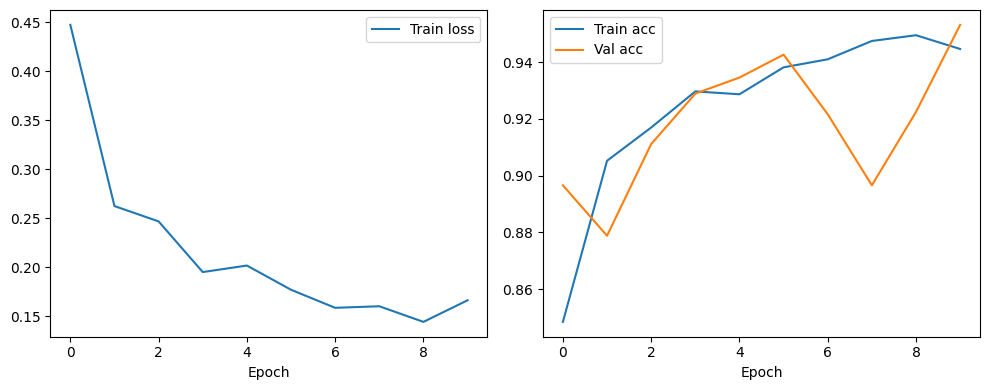

In [11]:
# Optional: plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(history["train_loss"], label="Train loss")
ax1.set_xlabel("Epoch")
ax1.legend()
ax2.plot(history["train_acc"], label="Train acc")
ax2.plot(history["val_acc"], label="Val acc")
ax2.set_xlabel("Epoch")
ax2.legend()
plt.tight_layout()
plt.show()

In [12]:
# Load best checkpoint from export/ and evaluate
# Ensure model architecture is defined (use same as training)
if 'model' not in globals():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(device)

model.load_state_dict(torch.load("export/maize_disease_model.pt", map_location=device))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device)
        logits = model(X)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(pred)
        all_labels.extend(y.numpy())

report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
cm = confusion_matrix(all_labels, all_preds)

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))
print("Confusion Matrix:")
print(cm)

Classification Report:
                precision    recall  f1-score   support

        Blight       0.92      0.89      0.90       229
   Common_Rust       0.98      0.97      0.97       261
Gray_Leaf_Spot       0.82      0.92      0.87       115
       Healthy       1.00      1.00      1.00       233
           MLB       0.98      0.94      0.96       200
           MSV       0.96      0.99      0.98       200

      accuracy                           0.95      1238
     macro avg       0.94      0.95      0.95      1238
  weighted avg       0.95      0.95      0.95      1238

Confusion Matrix:
[[203   2  22   0   2   0]
 [  4 252   2   1   0   2]
 [  8   0 106   0   1   0]
 [  0   0   0 233   0   0]
 [  5   2   0   0 187   6]
 [  0   1   0   0   0 199]]


**Graph: precision, recall, f1-score, support per class**  
The next cell plots the four metrics (precision, recall, f1-score, support) for each class as a grouped bar chart.

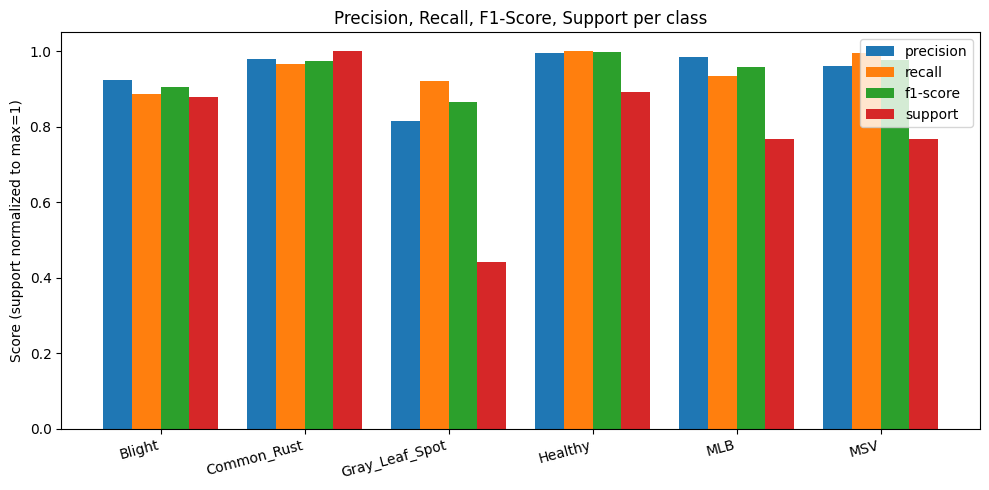

In [13]:
# Plot precision, recall, f1-score, support per class
metrics = ["precision", "recall", "f1-score", "support"]
x = np.arange(len(class_names))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
for i, m in enumerate(metrics):
    vals = [report_dict[c][m] for c in class_names]
    if m == "support":
        vals = [v / max(vals) if max(vals) > 0 else 0 for v in vals]  # scale for visibility
    offset = width * (i - 1.5)
    ax.bar(x + offset, vals, width, label=m)

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=15, ha="right")
ax.set_ylabel("Score (support normalized to max=1)")
ax.set_title("Precision, Recall, F1-Score, Support per class")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

**Confusion matrix heatmap**  
The next cell plots the confusion matrix as a heatmap with class names on both axes.

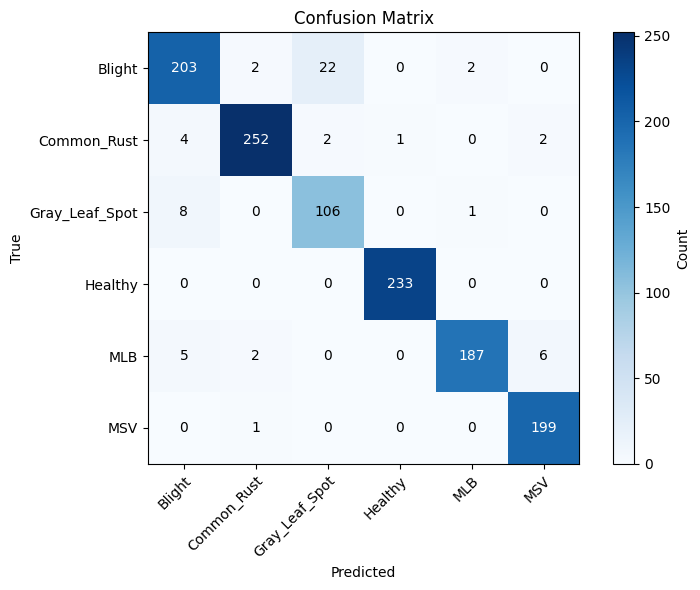

In [14]:
# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black" if cm[i, j] < cm.max() / 2 else "white")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")
fig.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()